# EDA 06 - Road Closures + Timetable (Merged)

**Source**: Output of `geo.find_nearby_stations()` + `features.filter_within_time_window()`  
**Reads from**: `data/processed/road_closures_clean.parquet` + `data/processed/darwin_timetable_clean.parquet`  
**Output**: `data/processed/road_timetable_dataset.parquet` - consumed by `rail_delay_prediction.ipynb` for forward prediction

This notebook performs EDA on the road closure + Darwin timetable merged dataset. Unlike the road + train moments dataset (EDA 05), this dataset contains **no actual timestamps** - it is the prediction dataset where planned service times are known but outcomes have not yet been observed. The goal is to understand the scheduled services that fall within the road closure impact zone before the model generates delay forecasts.

---
**Sections**
1. Rebuild the road + timetable dataset from processed parquets  
2. Dataset overview and shape  
3. Coverage comparison: timetable vs analytical (train moments)  
4. Predictor distributions (distance, time since closure)  
5. Categorical distributions (closure type, event type, TOC)  
6. Bivariate relationships (distance x time, correlation matrix)  
7. Scheduled service frequency by hour  
8. Spatial patterns (stations, closure impact on timetable)  
9. Planned time diff distribution within closure window  
10. Save output  


## 0. Setup

In [27]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_06_01", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Rebuild Road + Timetable Dataset

Read the processed parquets saved by EDA 02 (road closures) and EDA 04 (Darwin timetable), then re-run the spatial join and temporal filter using the timetable schedule instead of train moments. This mirrors the pipeline in the main analysis notebook.

In [3]:
from src.geo import find_nearby_stations
from src.features import reshape_timetable_to_schedule

# Road closures
road_df           = pd.read_parquet("./data/processed/road_closures_clean.parquet")
unplanned_road_df = pd.read_parquet("./data/processed/unplanned_road_closures.parquet")

# Timetable from eda_04
timetable_df      = pd.read_parquet("./data/processed/darwin_timetable_clean.parquet")

# Station reference
stations_ref_df   = pd.read_parquet("./data/processed/stations_reference.parquet")

# Ensure planned_date is datetime
timetable_df["planned_date"] = pd.to_datetime(timetable_df["planned_date"])

print("=== Input Shapes ===")
print(f"Road closures (all):       {len(road_df):,}")
print(f"Road closures (unplanned): {len(unplanned_road_df):,}")
print(f"Timetable stops (raw):     {len(timetable_df):,}")
print(f"Stations reference:        {len(stations_ref_df):,}")

print("\n=== Date Alignment Check ===")
print(f"Road closures:  {road_df['effective_start_time'].min()} — {road_df['effective_end_time'].max()}")
print(f"Timetable:      {timetable_df['planned_date'].min().date()} — {timetable_df['planned_date'].max().date()}")

=== Input Shapes ===
Road closures (all):       1,557
Road closures (unplanned): 1,006
Timetable stops (raw):     18,215,122
Stations reference:        2,594

=== Date Alignment Check ===
Road closures:  2026-04-10 00:00:00+00:00 — 2026-04-28 23:59:59+00:00
Timetable:      2026-04-09 — 2026-04-30


In [4]:
# reshape_timetable_to_schedule maps tpl → station_code (tlc) and stanox
# via stations_ref_df using tiploc as the join key
# Output columns: ssd, tpl, station_code, stanox, timetable_train_id,
#                 planned_timestamp, event_type
# All stop types retained — passing points included as scheduled services

schedule_df = reshape_timetable_to_schedule(timetable_df, stations_ref_df)

# Drop rows missing planned_timestamp or stanox — cannot be joined downstream
before = len(schedule_df)
schedule_df = schedule_df.dropna(subset=["planned_timestamp", "stanox"])
print(f"Dropped {before - len(schedule_df):,} rows missing planned_timestamp or stanox")

# Derive planned_date from ssd for station-day grouping
schedule_df["planned_date"] = pd.to_datetime(schedule_df["ssd"]).dt.normalize()

print(f"\nSchedule rows after reshape: {len(schedule_df):,}")
print(f"Columns: {list(schedule_df.columns)}")
print(f"Unique station_codes: {schedule_df['station_code'].nunique():,}")
print(f"Unique stanox:        {schedule_df['stanox'].nunique():,}")
print()
print("Event type distribution:")
print(schedule_df["event_type"].value_counts().to_string())
display(schedule_df.head(3))

Dropped 7,216,410 rows missing planned_timestamp or stanox

Schedule rows after reshape: 10,998,712
Columns: ['ssd', 'tpl', 'station_code', 'stanox', 'timetable_train_id', 'planned_timestamp', 'event_type', 'planned_date']
Unique station_codes: 2,529
Unique stanox:        2,529

Event type distribution:
event_type
ARRIVAL      8445263
PASS         1682580
DEPARTURE     870869


,ssd,tpl,station_code,stanox,timetable_train_id,planned_timestamp,event_type,planned_date
4,2026-04-10,QTRDBAT,QRB,87216,2S69,2026-04-10 21:29:00,ARRIVAL,2026-04-10
6,2026-04-10,WDWTOWN,WNT,87153,2S69,2026-04-10 21:34:30,ARRIVAL,2026-04-10
7,2026-04-10,PUTNEY,PUT,87152,2S69,2026-04-10 21:37:00,ARRIVAL,2026-04-10


In [5]:
# One row per station per day - mirrors eda_05_01 exactly
# train_movements = unique journey count (timetable_train_id)
# peak_services derived from planned_timestamp hour
# Rename train_movements to match model feature name used in station_modelling

schedule_df["sched_hour"] = schedule_df["planned_timestamp"].dt.hour
schedule_df["is_peak"] = schedule_df["sched_hour"].apply(
    lambda h: 1 if pd.notna(h) and (7 <= h <= 9 or 17 <= h <= 19) else 0
)

timetable_station_day = (
    schedule_df
    .groupby(["station_code", "stanox", "planned_date"], dropna=False)
    .agg(
        train_movements = ("timetable_train_id", "nunique"),
        peak_services   = ("is_peak",            "sum"),
    )
    .reset_index()
)

timetable_station_day["peak_service_share"] = (
    timetable_station_day["peak_services"]
    / timetable_station_day["train_movements"]
).round(4)

# Map station_name from stations_reference via stanox for readability
stanox_to_name = (
    stations_ref_df[["stanox", "station"]]
    .drop_duplicates(subset="stanox")
    .rename(columns={"station": "station_name"})
)
timetable_station_day = timetable_station_day.merge(
    stanox_to_name, on="stanox", how="left"
)

print(f"Timetable station-day rows: {len(timetable_station_day):,}")
print(f"Unique stations:            {timetable_station_day['station_name'].nunique():,}")
print(f"Date range:                 {timetable_station_day['planned_date'].min().date()} — {timetable_station_day['planned_date'].max().date()}")
print()
print("train_movements statistics:")
print(timetable_station_day["train_movements"].describe().round(2))
display(timetable_station_day.head(3))

Timetable station-day rows: 51,437
Unique stations:            2,529
Date range:                 2026-04-09 — 2026-04-30

train_movements statistics:
count    51437.00
mean       103.73
std        126.48
min          1.00
25%         34.00
50%         67.00
75%        126.00
max       1184.00
Name: train_movements, dtype: float64


,station_code,stanox,planned_date,train_movements,peak_services,peak_service_share,station_name
0,AAP,54103,2026-04-09,9,1,0.1111,Alexandra Palace
1,AAP,54103,2026-04-10,862,331,0.3840,Alexandra Palace
2,AAP,54103,2026-04-11,734,235,0.3202,Alexandra Palace


In [6]:
# All closures — full road environment for feature set
expanded_road_df = find_nearby_stations(
    road_df, stations_ref_df, min_km=10, max_km=25
)

# Unplanned separately — primary signal of interest
expanded_unplanned_df = find_nearby_stations(
    unplanned_road_df, stations_ref_df, min_km=10, max_km=25
)

print(f"Closure-station pairs (all):       {len(expanded_road_df):,}")
print(f"Closure-station pairs (unplanned): {len(expanded_unplanned_df):,}")
print(f"Unique stations with any closure:  {expanded_road_df['station_name'].nunique():,}")
print(f"Unique stations with unplanned:    {expanded_unplanned_df['station_name'].nunique():,}")

Closure-station pairs (all):       99,298
Closure-station pairs (unplanned): 75,415
Unique stations with any closure:  1,744
Unique stations with unplanned:    1,479


In [7]:
def expand_closures_to_days(df):
    """
    Explode each closure across every calendar day it is active.
    Bridges the temporal granularity gap between road closures
    (spanning days) and scheduled services (per-day).
    """
    df = df.copy()
    df["effective_start_time"] = pd.to_datetime(
        df["effective_start_time"], utc=True, errors="coerce"
    )
    df["effective_end_time"] = pd.to_datetime(
        df["effective_end_time"], utc=True, errors="coerce"
    )
    df = df.dropna(
        subset=["effective_start_time", "effective_end_time", "station_name"]
    )
    df["planned_date"] = df.apply(
        lambda row: pd.date_range(
            row["effective_start_time"].floor("D"),
            row["effective_end_time"].floor("D"),
            freq="D",
        ),
        axis=1,
    )
    df = df.explode("planned_date").copy()
    df["planned_date"] = pd.to_datetime(df["planned_date"])
    return df

road_station_day      = expand_closures_to_days(expanded_road_df)
unplanned_station_day = expand_closures_to_days(expanded_unplanned_df)

print(f"Road station-day rows (all):       {len(road_station_day):,}")
print(f"Road station-day rows (unplanned): {len(unplanned_station_day):,}")

Road station-day rows (all):       347,231
Road station-day rows (unplanned): 75,709


In [16]:
# total_closure_severity and max_road_class included
# to match eda_05_01 feature set exactly

road_station_day_agg = (
    road_station_day
    .groupby(["station_name", "stanox", "planned_date"], dropna=False)
    .agg(
        road_closure_count            = ("closure_id",               "nunique"),
        min_distance_km               = ("distance_in_km",           "min"),
        mean_distance_km              = ("distance_in_km",           "mean"),
        max_effective_duration_hours  = ("effective_duration_hours", "max"),
        mean_effective_duration_hours = ("effective_duration_hours", "mean"),
        inv_distance_sum              = ("distance_in_km",           lambda x: (1 / x).sum()),
        total_closure_severity        = ("closure_severity",         "sum"),
        max_road_class                = ("road_class",               "max"),
    )
    .reset_index()
)

# Unplanned closures counted separately
n_unplanned = (
    road_station_day[road_station_day["closure_type"] == "unplanned"]
    .groupby(["station_name", "stanox", "planned_date"])["closure_id"]
    .nunique()
    .reset_index(name="n_unplanned_closures")
)
road_station_day_agg = road_station_day_agg.merge(
    n_unplanned, on=["station_name", "stanox", "planned_date"], how="left"
)
road_station_day_agg["n_unplanned_closures"] = (
    road_station_day_agg["n_unplanned_closures"].fillna(0).astype(int)
)
road_station_day_agg["has_road_closure"] = (
    road_station_day_agg["road_closure_count"] > 0
).astype(int)

print(f"Aggregated road station-day rows: {len(road_station_day_agg):,}")
display(road_station_day_agg.head(3))

Aggregated road station-day rows: 26,658


,station_name,stanox,planned_date,road_closure_count,min_distance_km,mean_distance_km,max_effective_duration_hours,mean_effective_duration_hours,inv_distance_sum,total_closure_severity,max_road_class,n_unplanned_closures,has_road_closure
0,Abbey Wood,88601,2026-04-10 00:00:00+00:00,7,10.191189,18.115876,6.5,2.357143,0.414091,49.50,3,4,1
1,Abbey Wood,88601,2026-04-11 00:00:00+00:00,3,13.397358,18.104797,8.0,4.916667,0.176387,44.25,3,1,1
2,Abbey Wood,88601,2026-04-12 00:00:00+00:00,3,11.301188,17.208552,8.0,5.791667,0.381811,91.25,3,1,1


In [19]:
road_station_day_agg["planned_date"] = (
    road_station_day_agg["planned_date"].dt.tz_localize(None)
)

print(timetable_station_day["planned_date"].dtype)
print(road_station_day_agg["planned_date"].dtype)

datetime64[s]
datetime64[us]


In [22]:
# Join on stanox + planned_date
# station_name comes from road aggregation where available
# station_code (tlc) from timetable side is retained for reference
import numpy as np
ROAD_COLS = [
    "road_closure_count", "n_unplanned_closures",
    "min_distance_km", "mean_distance_km",
    "max_effective_duration_hours", "mean_effective_duration_hours",
    "inv_distance_sum", "total_closure_severity",
    "max_road_class", "has_road_closure",
]

timetable_road_df = timetable_station_day.merge(
    road_station_day_agg,
    on=["stanox", "planned_date"],
    how="left",
    suffixes=("_timetable", "_road")
)

# Resolve station_name — prefer road side (spatially validated)
# fall back to timetable side if road side is null
if "station_name_road" in timetable_road_df.columns:
    timetable_road_df["station_name"] = timetable_road_df[
        "station_name_road"
    ].fillna(timetable_road_df.get("station_name_timetable", np.nan))
    timetable_road_df = timetable_road_df.drop(
        columns=[c for c in ["station_name_road", "station_name_timetable"]
                 if c in timetable_road_df.columns]
    )

for col in ROAD_COLS:
    if col in timetable_road_df.columns:
        timetable_road_df[col] = timetable_road_df[col].fillna(0)

print(f"Merged dataset shape: {timetable_road_df.shape}")
print(f"Rows with closure:    {timetable_road_df['has_road_closure'].sum():,} ({timetable_road_df['has_road_closure'].mean()*100:.1f}%)")
print(f"Rows without closure: {(timetable_road_df['has_road_closure']==0).sum():,} ({(1-timetable_road_df['has_road_closure'].mean())*100:.1f}%)")

Merged dataset shape: (51437, 17)
Rows with closure:    26,092.0 (50.7%)
Rows without closure: 25,345 (49.3%)


##  Temporal and Lag Features

In [24]:
# Consistent with eda_05_01
timetable_road_df["day_of_week"] = timetable_road_df["planned_date"].dt.dayofweek
timetable_road_df["is_weekend"]  = timetable_road_df["day_of_week"].isin([5, 6]).astype(int)
timetable_road_df["is_monday"]   = (timetable_road_df["day_of_week"] == 0).astype(int)
timetable_road_df["is_friday"]   = (timetable_road_df["day_of_week"] == 4).astype(int)

# Sort before rolling — critical for correctness
timetable_road_df = timetable_road_df.sort_values(
    ["stanox", "planned_date"]
).reset_index(drop=True)

for window in [1, 3, 7]:
    timetable_road_df[f"closures_lag{window}d"] = (
        timetable_road_df
        .groupby("stanox")["road_closure_count"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).sum())
        .fillna(0)
    )

print("Temporal and lag features added.")
print(timetable_road_df[[
    "station_name", "stanox", "planned_date", "day_of_week",
    "is_friday", "closures_lag1d", "closures_lag3d", "closures_lag7d"
]].head(5).to_string())

Temporal and lag features added.
  station_name stanox planned_date  day_of_week  is_friday  closures_lag1d  closures_lag3d  closures_lag7d
0       Thurso  01001   2026-04-10            4          1             0.0             0.0             0.0
1       Thurso  01001   2026-04-11            5          0             0.0             0.0             0.0
2       Thurso  01001   2026-04-12            6          0             0.0             0.0             0.0
3       Thurso  01001   2026-04-13            0          0             0.0             0.0             0.0
4       Thurso  01001   2026-04-14            1          0             0.0             0.0             0.0


## 2. Dataset Overview

In [25]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"Total rows:              {len(timetable_road_df):,}")
print(f"Unique stanox:           {timetable_road_df['stanox'].nunique():,}")
print(f"Unique station codes:    {timetable_road_df['station_code'].nunique():,}")
print(f"Date range:              {timetable_road_df['planned_date'].min().date()} to {timetable_road_df['planned_date'].max().date()}")
print(f"With any closure:        {timetable_road_df['has_road_closure'].sum():,} ({timetable_road_df['has_road_closure'].mean()*100:.1f}%)")
print(f"With unplanned closure:  {(timetable_road_df['n_unplanned_closures']>0).sum():,} ({(timetable_road_df['n_unplanned_closures']>0).mean()*100:.1f}%)")
print()

dupes = (
    timetable_road_df
    .groupby(["stanox", "planned_date"])
    .size()
    .pipe(lambda s: s[s > 1])
)
print(f"Duplicate stanox-date rows: {len(dupes):,}")
print()
print(f"Final columns ({len(timetable_road_df.columns)}):")
print(list(timetable_road_df.columns))

FINAL DATASET SUMMARY
Total rows:              51,437
Unique stanox:           2,529
Unique station codes:    2,529
Date range:              2026-04-09 to 2026-04-30
With any closure:        26,092.0 (50.7%)
With unplanned closure:  19,016 (37.0%)

Duplicate stanox-date rows: 0

Final columns (24):
['station_code', 'stanox', 'planned_date', 'train_movements', 'peak_services', 'peak_service_share', 'road_closure_count', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'total_closure_severity', 'max_road_class', 'n_unplanned_closures', 'has_road_closure', 'station_name', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'closures_lag1d', 'closures_lag3d', 'closures_lag7d']


## EDA
### Scheduled Services Distribution

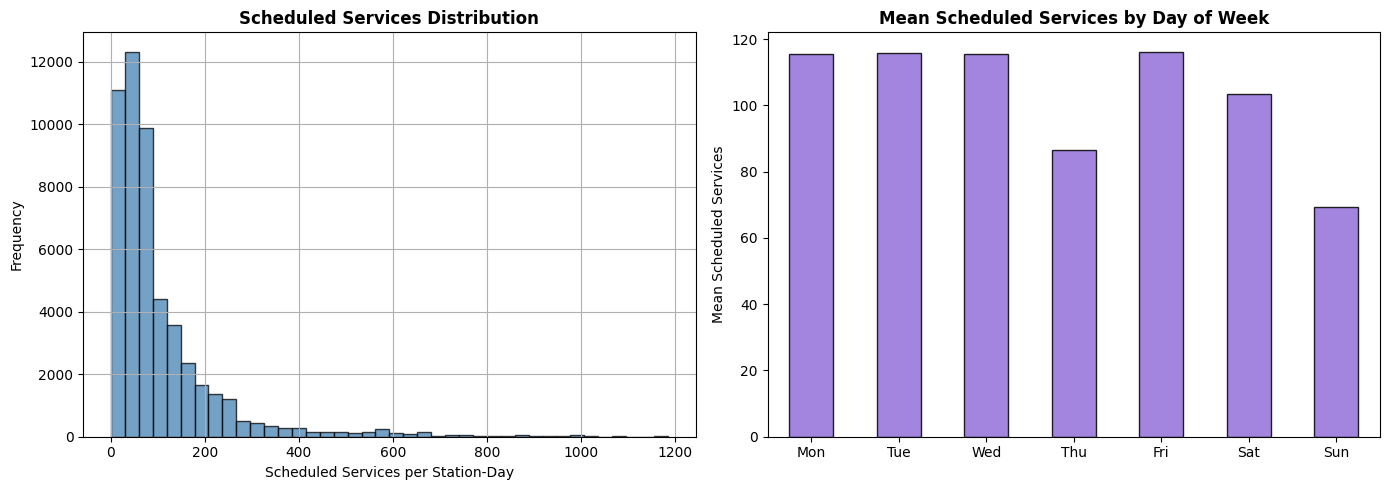

In [28]:
DOW_MAP = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

timetable_road_df["train_movements"].hist(
    bins=40, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue"
)
axes[0].set_xlabel("Scheduled Services per Station-Day")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Scheduled Services Distribution", fontweight="bold")

dow_services = timetable_road_df.groupby("day_of_week")["train_movements"].mean()
dow_services.index = [DOW_MAP[i] for i in dow_services.index]
dow_services.plot(kind="bar", ax=axes[1], color="mediumpurple",
                  edgecolor="black", alpha=0.85)
axes[1].set_title("Mean Scheduled Services by Day of Week", fontweight="bold")
axes[1].set_ylabel("Mean Scheduled Services")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("figures/eda_06_01/scheduled_services.png", dpi=200, bbox_inches="tight")
plt.show()

### Closure Feature Distribtuions

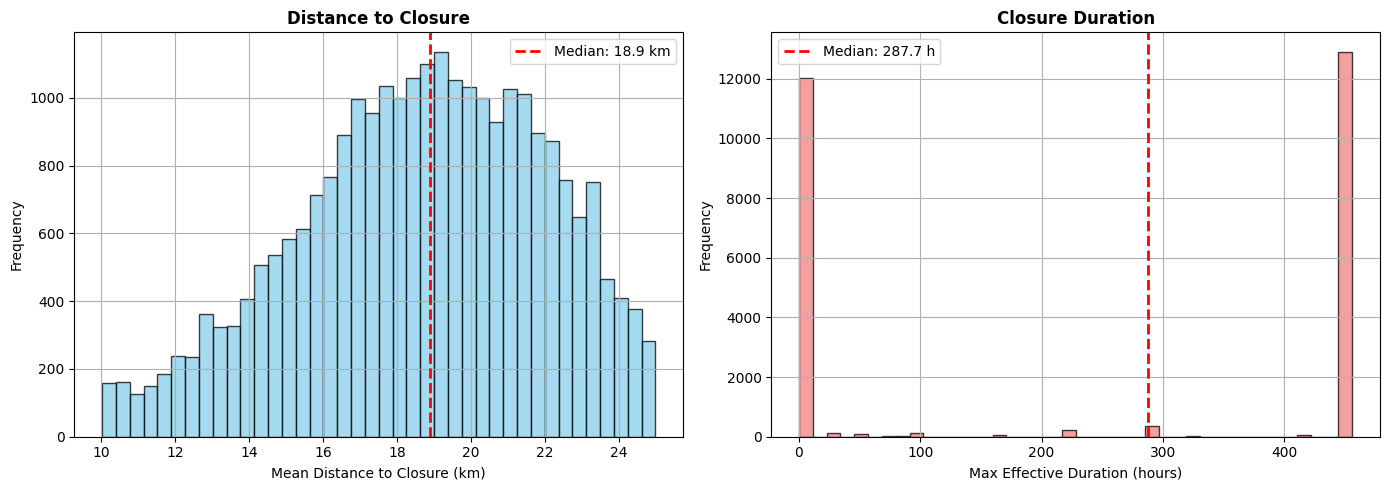

Distance statistics (closure rows only):
count    26092.00
mean        18.66
std          3.32
min         10.02
25%         16.45
50%         18.89
75%         21.24
max         25.00
Name: mean_distance_km, dtype: float64

Duration statistics (closure rows only):
count    26092.00
mean       235.31
std        223.22
min          0.18
25%          0.25
50%        287.72
75%        456.00
max        456.00
Name: max_effective_duration_hours, dtype: float64


In [29]:
closure_rows = timetable_road_df[timetable_road_df["has_road_closure"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

closure_rows["mean_distance_km"].hist(
    bins=40, ax=axes[0], edgecolor="black", alpha=0.75, color="skyblue"
)
axes[0].axvline(closure_rows["mean_distance_km"].median(),
                color="red", linestyle="--", lw=2,
                label=f"Median: {closure_rows['mean_distance_km'].median():.1f} km")
axes[0].set_xlabel("Mean Distance to Closure (km)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distance to Closure", fontweight="bold")
axes[0].legend()

closure_rows["max_effective_duration_hours"].hist(
    bins=40, ax=axes[1], edgecolor="black", alpha=0.75, color="lightcoral"
)
axes[1].axvline(closure_rows["max_effective_duration_hours"].median(),
                color="red", linestyle="--", lw=2,
                label=f"Median: {closure_rows['max_effective_duration_hours'].median():.1f} h")
axes[1].set_xlabel("Max Effective Duration (hours)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Closure Duration", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/eda_06_01/closure_feature_distributions.png",
            dpi=200, bbox_inches="tight")
plt.show()

print("Distance statistics (closure rows only):")
print(closure_rows["mean_distance_km"].describe().round(2))
print("\nDuration statistics (closure rows only):")
print(closure_rows["max_effective_duration_hours"].describe().round(2))

### Comparision with Train Movements Dataset

Stanox coverage comparison:
  Timetable stanox:           2,529
  Train moments stanox:       2,506
  In both:                    2,103
  Timetable only:             426
  Train moments only:         403

Row count comparison:
  Timetable station-days:     51,437
  Train moment station-days:  33,941
  Ratio:                      1.5x


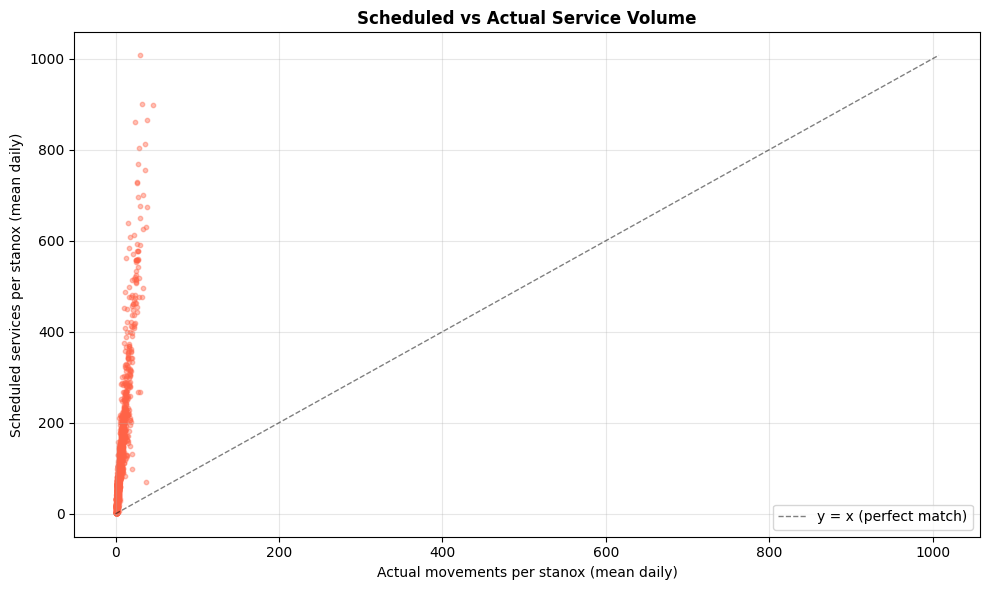

In [30]:
train_station_day = pd.read_parquet("./data/processed/train_station_day.parquet")

t_stanox = set(timetable_road_df["stanox"].dropna().astype(str))
m_stanox = set(train_station_day["stanox"].dropna().astype(str))

print("Stanox coverage comparison:")
print(f"  Timetable stanox:           {len(t_stanox):,}")
print(f"  Train moments stanox:       {len(m_stanox):,}")
print(f"  In both:                    {len(t_stanox & m_stanox):,}")
print(f"  Timetable only:             {len(t_stanox - m_stanox):,}")
print(f"  Train moments only:         {len(m_stanox - t_stanox):,}")
print()
print("Row count comparison:")
print(f"  Timetable station-days:     {len(timetable_road_df):,}")
print(f"  Train moment station-days:  {len(train_station_day):,}")
print(f"  Ratio:                      {len(timetable_road_df)/len(train_station_day):.1f}x")

# Service volume at overlapping stanox
overlap = list(t_stanox & m_stanox)
t_vol = (
    timetable_road_df[timetable_road_df["stanox"].astype(str).isin(overlap)]
    .groupby("stanox")["train_movements"].mean()
)
m_vol = (
    train_station_day[train_station_day["stanox"].astype(str).isin(overlap)]
    .groupby("stanox")["train_movements"].mean()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    m_vol,
    t_vol.reindex(m_vol.index),
    alpha=0.4, s=10, color="tomato"
)
lim = max(m_vol.max(), t_vol.max())
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5,
        label="y = x (perfect match)")
ax.set_xlabel("Actual movements per stanox (mean daily)")
ax.set_ylabel("Scheduled services per stanox (mean daily)")
ax.set_title("Scheduled vs Actual Service Volume", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/eda_06_01/scheduled_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

### Top Stations by Scheduled Services

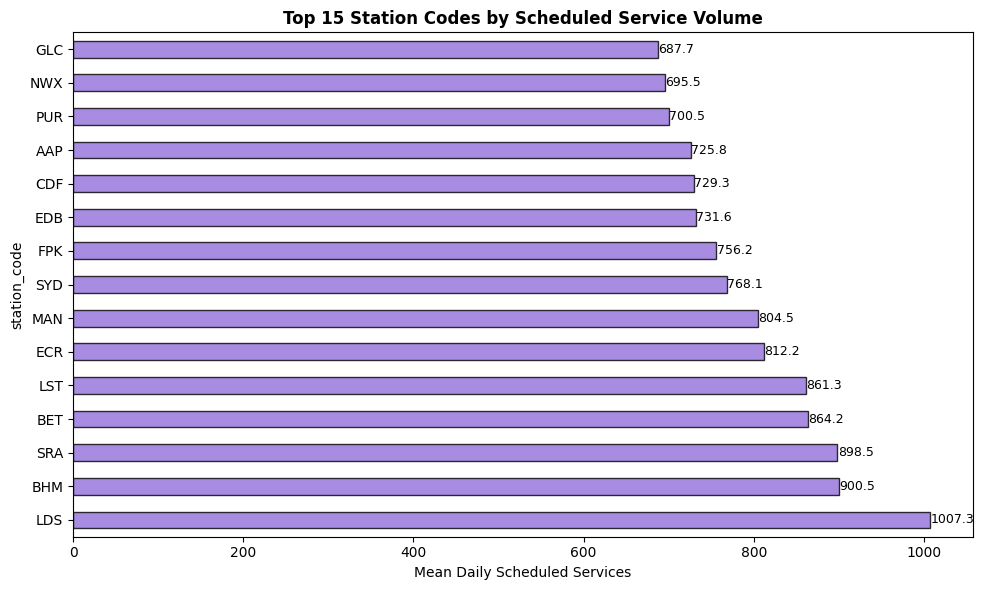

In [31]:
top_stations = (
    timetable_road_df
    .groupby("station_code")["train_movements"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
top_stations.plot(kind="barh", color="mediumpurple",
                  edgecolor="black", alpha=0.8)
plt.xlabel("Mean Daily Scheduled Services")
plt.title("Top 15 Station Codes by Scheduled Service Volume", fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_06_01/top_stations_scheduled.png", dpi=200, bbox_inches="tight")
plt.show()

### Service Density Heatmap (Distance x Duration)

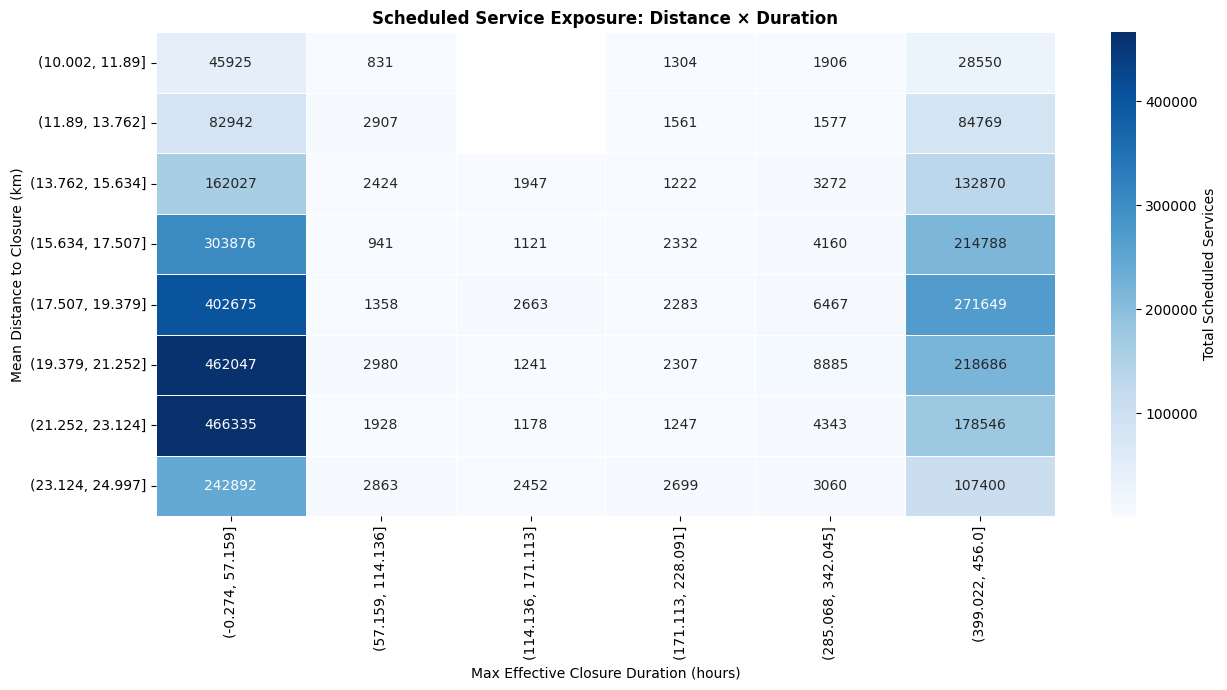

In [32]:
hm = timetable_road_df[timetable_road_df["has_road_closure"] == 1].copy()
hm["dist_bin"] = pd.cut(hm["mean_distance_km"],             bins=8)
hm["dur_bin"]  = pd.cut(hm["max_effective_duration_hours"], bins=8)

pivot = hm.pivot_table(
    values="train_movements",
    index="dist_bin",
    columns="dur_bin",
    aggfunc="sum"
)

plt.figure(figsize=(13, 7))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "Total Scheduled Services"},
            linewidths=0.5)
plt.xlabel("Max Effective Closure Duration (hours)")
plt.ylabel("Mean Distance to Closure (km)")
plt.title("Scheduled Service Exposure: Distance × Duration", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_06_01/heatmap_service_density.png", dpi=200, bbox_inches="tight")
plt.show()

In [33]:
OUT_PATH = "./data/processed/road_timetable_station_day.parquet"
timetable_road_df.to_parquet(OUT_PATH, index=False)

print(f"Saved: {OUT_PATH}")
print(f"Shape: {timetable_road_df.shape}")
print()
timetable_road_df.info()

Saved: ./data/processed/road_timetable_station_day.parquet
Shape: (51437, 24)

<class 'pandas.DataFrame'>
RangeIndex: 51437 entries, 0 to 51436
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype        
---  ------                         --------------  -----        
 0   station_code                   51437 non-null  str          
 1   stanox                         51437 non-null  str          
 2   planned_date                   51437 non-null  datetime64[s]
 3   train_movements                51437 non-null  int64        
 4   peak_services                  51437 non-null  int64        
 5   peak_service_share             51437 non-null  float64      
 6   road_closure_count             51437 non-null  float64      
 7   min_distance_km                51437 non-null  float64      
 8   mean_distance_km               51437 non-null  float64      
 9   max_effective_duration_hours   51437 non-null  float64      
 10  mean_effective_duration_ho